In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder

In [2]:
titanic = pd.read_csv('./data/titanic.csv')

In [3]:
titanic.head(7)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S


Let's start by building a model using Age as a predictor variable.

When performing a train/test split, you usually want to make sure that the ratios of target values look the same in the training set and in the test set. This is especially true with imbalanced targets, where there are more observations in one class than the other. This can be done by, instead of a completely random split, by performing a stratified split.

Create a DataFrame, X, which contains one column, Age, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split.

In [4]:
target_variables = ['Age']
X = titanic[target_variables]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

Now, try and fit a logistic regression model using the LogisticRegression class. When you do this, you're likely to encounter an error, that "Input X contains NaN." If you check, you'll find that there are some missing values in the Age column. In the next step, we'll address this issue.

In [5]:
#clf = LogisticRegression(random_state=0).fit(X_train, y_train)

One option when a column contains missing values is to impute them, meaning to replace the missing values with an estimate. A simple way to impute is to fill missing values using the mean value. Important Note: When imputing with the mean, you should calculate the mean value only on the training data. In order to have an unbiased estimate of model performance, it is important that the model has access to no information about the test set.

Using a SimpleImputer, fit the training data and then use it to transform both the training and test data.

In [6]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [7]:
imp_mean.fit(X_train)

SimpleImputer()

In [8]:
X_train = imp_mean.transform(X_train)
X_test = imp_mean.transform(X_test)

Now, fit your logistic regression model to the training data and generate predictions on the test data.

In [9]:
clf = LogisticRegression(random_state=0).fit(X_train, y_train)

In [10]:
y_pred = clf.predict(X_test)

There are multiple ways we can assess the performance of a classification model. A common way is put those predictions into a confusion matrix, which compares the predicted and actual values.

Create a confusion matrix out of the predictions. What do you find?

In [11]:
confusion_matrix(y_test, y_pred)

array([[165,   0],
       [103,   0]])

The model did not predict that anyone survived. It correctly predicted 165 deaths, and incorrectly predicted 103 deaths.

Plot the ROC curve. How well does your model do? Hint: You can use the RocCurveDisplay to create this plot.

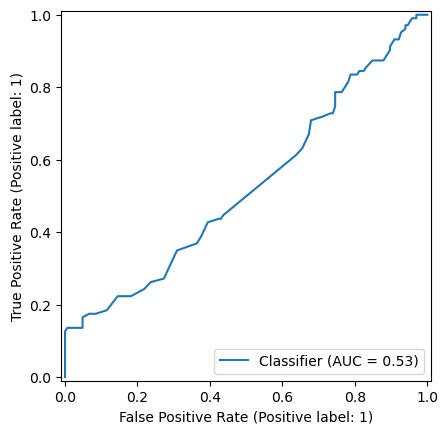

In [12]:
y_score = clf.decision_function(X_test)
RocCurveDisplay.from_predictions(y_test, y_score);

The model doesn't do much better than a random uninformed selection (which would yield AUC = 0.5).

You are likely to see that the model does not tend to predict that individuals survived the voyage. Let's see if we can determine why.

Look at the average age of survivors vs. those that did not survive the voyage. What do you find?

In [13]:
titanic.groupby('Survived').agg({'Age':'mean'})

,Age
Survived,
0,30.626179
1,28.343690


The average age of survivors is slightly lower than non-survivors (28.3 vs 30.6).

Perhaps the actual age number is as important as whether a passenger was a child or an adult. Create a Boolean column that indicates whether a passenger was a child or an adult. Pick a cutoff age and if they were less than this age, label as a child. We'll see later on how we can make choosing the age part of our model building pipeline, but for now, choose an age or do some calculations to pick an age that you think might do well.

In [14]:
titanic['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [15]:
titanic['Child'] = titanic['Age'] < 20

When imputing the missing values, you'll need to change the strategy from mean to most_frequent. Impute the missing values, then fit the model using this new variable, generate predictions, and view the confusion matrix. How did your model do?

In [16]:
target_variables = ['Child']
X = titanic[target_variables]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

imp_mean.fit(X_train)

X_train = imp_mean.transform(X_train)
X_test = imp_mean.transform(X_test)

clf = LogisticRegression(random_state=0).fit(X_train, y_train)

y_pred = clf.predict(X_test)

confusion_matrix(y_test, y_pred)

array([[165,   0],
       [103,   0]])

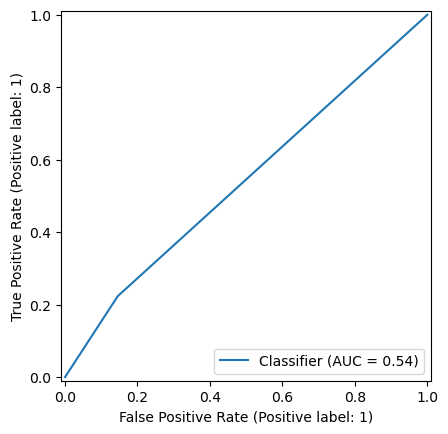

In [17]:
y_score = clf.decision_function(X_test)
RocCurveDisplay.from_predictions(y_test, y_score);

When using child status (age less than 20) instead of age, the confusion matrix does not change but the AUC gets a bit better (0.54 compared to 0.54).

Other common metrics for classification include accuracy, precision, and recall. For more information, see https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall. These metrics can be viewed using the classification_report function.

Generate a classification report for your model.

In [18]:
target_names = ['Perished','Survived']
print(classification_report(y_test, y_pred, target_names=target_names, zero_division = np.nan))

              precision    recall  f1-score   support

    Perished       0.62      1.00      0.76       165
    Survived        nan      0.00      0.00       103

    accuracy                           0.62       268
   macro avg       0.62      0.50      0.38       268
weighted avg       0.62      0.62      0.47       268



Another important variable is the Sex variable.

Create a DataFrame, X, which contains one column, Sex, and a Series, y, which contains the target variable. Perform a 70/30 train/test split, stratifying by the target variable. Make sure that you set a random_state during this split.

In [19]:
target_variables = ['Sex']
X = titanic[target_variables]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

If you inspect the Sex variable, you'll find that it is encoded as a string. We need to convert it to a numeric type so that our model can use it. We can do this using a OneHotEncoder.

In [20]:
X.dtypes

Sex    object
dtype: object

Fit a OneHotEncoder to the training data and then transform both the training and test sets. Fit a model and evaluate the performance of this model.

In [22]:
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(X_train)
X_train = enc.transform(X_train).toarray()
X_test = enc.transform(X_test).toarray()

clf = LogisticRegression(random_state=0).fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [24]:
confusion_matrix(y_test, y_pred)

array([[141,  24],
       [ 32,  71]])

In [23]:
target_names = ['Perished','Survived']
print(classification_report(y_test, y_pred, target_names=target_names, zero_division = np.nan))

              precision    recall  f1-score   support

    Perished       0.82      0.85      0.83       165
    Survived       0.75      0.69      0.72       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



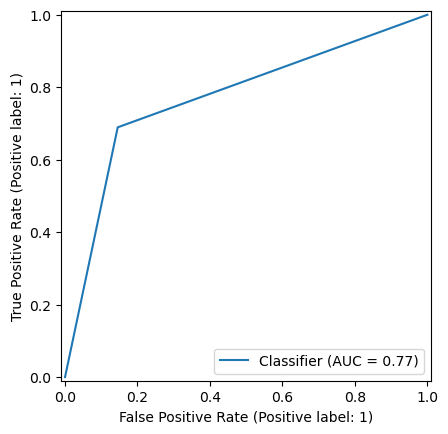

In [25]:
y_score = clf.decision_function(X_test)
RocCurveDisplay.from_predictions(y_test, y_score);

Using sex instead of age improved the precision of the model